# VISUALIZING THE BOUNDARY OF THE MODEL



In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

import pickle

In [2]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [3]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [12]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "german_credit"
dt_name = "toy_dataset"

cf_method = 'ils'#dice or lore



name_dataset = {"german_credit": "German Credit", 
                "adult": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [13]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/toy_dataset/feature_names.csv
Loaded X_train from data/processed/toy_dataset/X_train.npz
Loaded y_train from data/processed/toy_dataset/y_train.npz
Loaded X_test from data/processed/toy_dataset/X_test.npz
Loaded y_test from data/processed/toy_dataset/y_test.npz
Loaded X_calibration from data/processed/toy_dataset/X_calibration.npz
Loaded y_calibration from data/processed/toy_dataset/y_calibration.npz


In [14]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for toy_dataset
Loaded random_forest model from models/toy_dataset/random_forest.pkl
Loaded existing random_forest model
Processing mlp for toy_dataset
Loaded mlp model from models/toy_dataset/mlp.pkl
Loaded existing mlp model
Processing xgboost for toy_dataset
Loaded xgboost model from models/toy_dataset/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for toy_dataset
Loaded lgbm model from models/toy_dataset/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


## Load the distances files

In [15]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


Loaded ils/toy_dataset_ranking_latent.pkl
Loaded ils/toy_dataset_ranking_test_latent.pkl


In [16]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [17]:

# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats[k]['distances'][metric][stat] = np.array(all_stats[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats[k]['distances'][metric][stat]))
                for e in all_stats[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats[k]['probabs'] = np.array(all_stats[k]['probabs'])
    all_stats[k]['corrects'] = np.array(all_stats[k]['corrects']).reshape(-1)
    all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])

In [18]:
# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats_test[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats_test[k]['distances'][metric][stat] = np.array(all_stats_test[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats_test[k]['distances'][metric][stat]))
                for e in all_stats_test[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats_test[k]['probabs'] = np.array(all_stats_test[k]['probabs'])
    all_stats_test[k]['corrects'] = np.array(all_stats_test[k]['corrects']).reshape(-1)
    all_stats_test[k]['mean_conf'] = np.array(all_stats_test[k]['mean_conf'])

In [19]:
# let's seek the outliers (if any) by using the iforest algorithm
from sklearn.ensemble import IsolationForest
anomaly_detector = IsolationForest(contamination=0.05,random_state=42)

anomaly_detector.fit(splits["X_train"])#,sample_weight=class_w[splits["y_train"]])
anomalies = anomaly_detector.predict(splits["X_calibration"])<0
print("Found",anomalies.sum(),"anomalies")

# anomaly_detector2 = IsolationForest(contamination=0.05,random_state=42)
# anomaly_detector2.fit(splits["X_train"],sample_weight=class_w[splits["y_train"]].reshape(-1))
# anomalies2 = anomaly_detector2.predict(splits["X_calibration"])<0
# print("Found",anomalies2.sum(),"anomalies with class weights")
# anomalies_test = anomaly_detector.predict(splits["X_test"])<0
# print("Found",anomalies_test.sum(),"anomalies in the test set")

Found 12 anomalies


In [20]:

class_labels = ["Class 0","Class 1"]

In [21]:
importlib.reload(fplt)

<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [22]:
# set monospace font for rc params
plt.rcParams['font.family'] = 'monospace'

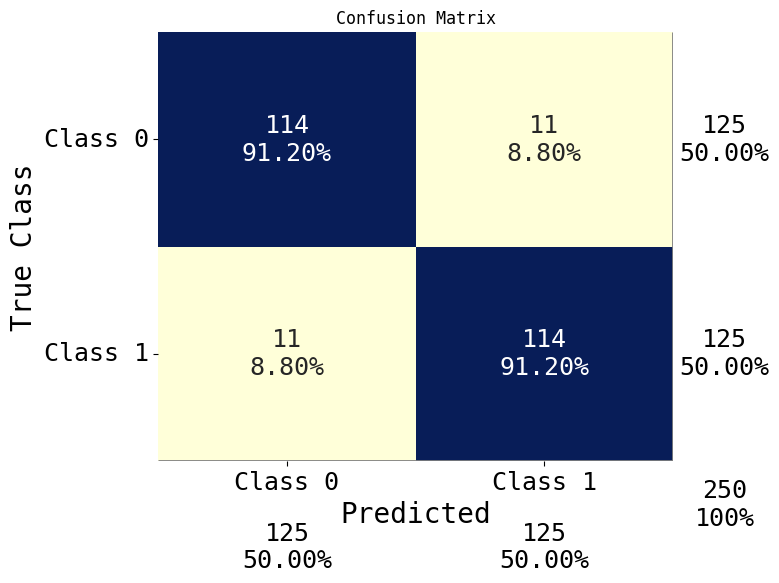

In [23]:
y_test = splits['y_test']
X_test = splits['X_test']
y_pred = models["mlp"].predict(X_test)

fplt.plot_confusion_matrix(y_test, y_pred, class_labels=class_labels,cmap='YlGnBu')

In [24]:
# now we do cool thing. We train a BernulliRBM to have a projection of the data in a two dimentional space (using the train split.)
# we then use the RBM to map 2d points to the original space and we plot the decision boundary of the original points but in the 2d space
# we then take few examples and we plot the counterfactuals in the 2d space. The few examples are the one with the smallest distance, the one with the largest distance, the one with a mid distance... 

from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class TrivialMapper():
    def __init__(self):
        pass
    def fit(self,X,y):
        pass
    def transform(self,X):
        return X
    def fit_transform(self,X,y):
        return X
    def inverse_transform(self,X):
        return X
    

mapper_ = Pipeline(steps=[
    ('scaler', models["random_forest"].named_steps['scaler']),
    ('mapper', TrivialMapper())#PCA(n_components=2)),#('rbm', BernoulliRBM(n_components=2, n_iter=100, random_state=0)),
    #('classifier', LogisticRegression(random_state=0))
])

mapper_.fit(splits['X_train'], splits['y_train'])

mapped_X = mapper_.transform(splits['X_test'])
mapped_X.shape

(250, 2)

In [25]:
class RBMInverseTransformer:
    def __init__(self, rbm):
        self.rbm = rbm

    def transform(self, X_transformed):
        """Approximate the inverse using RBM's weights and biases."""
        hidden_to_visible_weights = self.rbm.components_.T
        visible_bias = self.rbm.intercept_visible_

        # Perform the inverse transformation (logistic approximation)
        X_reconstructed = X_transformed @ hidden_to_visible_weights.T + visible_bias
        return X_reconstructed
    
inverse_mapper = Pipeline(steps=[
    ('imapper_', RBMInverseTransformer(mapper_.named_steps['mapper'])),
    #('inverse_scaler', mapper_rbm.named_steps['scaler'])
])

# Define the inverse PCA mapper
class InversePCAMapper:
    def __init__(self, scaler, pca):
        self.scaler = scaler
        self.pca = pca

    def transform(self, X_transformed):
        """
        Inverse the PCA transformation to map back to original scaled space.
        """
        # Inverse PCA to get back to scaled space
        X_scaled = self.pca.inverse_transform(X_transformed)
        # Inverse scaling to get back to the original space
        return self.scaler.inverse_transform(X_scaled)

inverse_pca = InversePCAMapper(scaler=mapper_.named_steps['scaler'], pca=mapper_.named_steps['mapper'])

inverse_mapper = inverse_pca



In [26]:
mapper_

Pipeline(steps=[('scaler', StandardScaler()),
                ('mapper', <__main__.TrivialMapper object at 0x7fcb11fc6880>)])

## How many mapped original points get classified in the same way to the original space points

In [27]:

_x_transformed = mapper_.transform(splits['X_train'])
_x_reconstructed = inverse_mapper.transform(_x_transformed)
_y_pred = models["random_forest"].predict(_x_reconstructed)
y_pred_train = models["random_forest"].predict(splits['X_train'])
print("Accuracy on the train",accuracy_score(_y_pred,y_pred_train))



Accuracy on the train 1.0


In [28]:
compute_test = True
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [29]:
def load_cf(k):
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz")]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)
    return cfs

In [30]:
# Just as a try
cfs = load_cf(k)
cfs["cfs"][3].keys()


I found 4 files
0) cf_results_lore_genetic_test_20250306_204931.npz
1) cf_results_ils_latent_test_20250216_163733.npz
2) cf_results_ils_random_test_20250209_223004.npz
3) cf_results_dice_kdtree_test_20250123_074659.npz
for model lgbm using file cf_results_lore_genetic_test_20250306_204931.npz
checking cf_results_lore_genetic_test_20250306_204931.npz


dict_keys(['instance_idx', 'original_instance', 'true_class', 'counterfactuals', 'rule', 'deltas', 'metadata'])

In [31]:
X_test.values[32]

array([-0.39752469,  0.10199448])

In [32]:
X_train_2d = mapper_.transform(splits['X_train'])
X_cal_2d = mapper_.transform(splits['X_calibration'])
X_test_2d = mapper_.transform(splits['X_test'])


In [33]:
# choose some samples from the test set
test_idx = np.random.choice(np.arange(len(X_test_2d)),size=20,replace=False)

from sklearn.cluster import KMeans
# we use kmeans to cluster the test set and then we take the closest sample to the center of each cluster
kmeans = KMeans(n_clusters=20, random_state=42)
kmeans.fit(X_test_2d)
centers = kmeans.cluster_centers_
# now we find the closest sample to each center
closest_samples = []
for center in centers:
    distances = np.linalg.norm(X_test_2d - center, axis=1)
    closest_sample_idx = np.argmin(distances)
    closest_samples.append(closest_sample_idx)
test_idx = closest_samples
print("Selected test samples:",test_idx)

Selected test samples: [215, 190, 234, 150, 139, 65, 194, 64, 172, 53, 132, 12, 236, 182, 146, 63, 124, 210, 10, 196]


2025-07-26 14:34:23,009 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 4 files
0) cf_results_lore_genetic_test_20250306_204607.npz
1) cf_results_ils_latent_test_20250216_163716.npz
2) cf_results_ils_random_test_20250209_222949.npz
3) cf_results_dice_kdtree_test_20250122_171749.npz
for model random_forest using file cf_results_lore_genetic_test_20250306_204607.npz
checking cf_results_lore_genetic_test_20250306_204607.npz
Found 2 counterfactuals for model random_forest
L2 distances computed (633,) (1, 2)
Original sample marker: *
original class was: 0      0
1      0
2      0
3      0
4      0
      ..
628    0
629    0
630    0
631    0
632    0
Name: target, Length: 633, dtype: int64
L2 distances computed (642,) (1, 2)
Original sample marker: s
original class was: 0      1
1      1
2      1
3      1
4      1
      ..
637    1
638    1
639    1
640    1
641    1
Name: target, Length: 642, dtype: int64
L2 distances computed (640,) (1, 2)
Original sample marker: *
original class was: 0      0
1      0
2      0
3      0
4      0
      ..
635    0
636 

2025-07-26 14:34:38,038 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


original class was: 0      0
1      0
2      0
3      0
4      0
      ..
647    0
648    0
649    0
650    0
651    0
Name: target, Length: 652, dtype: int64


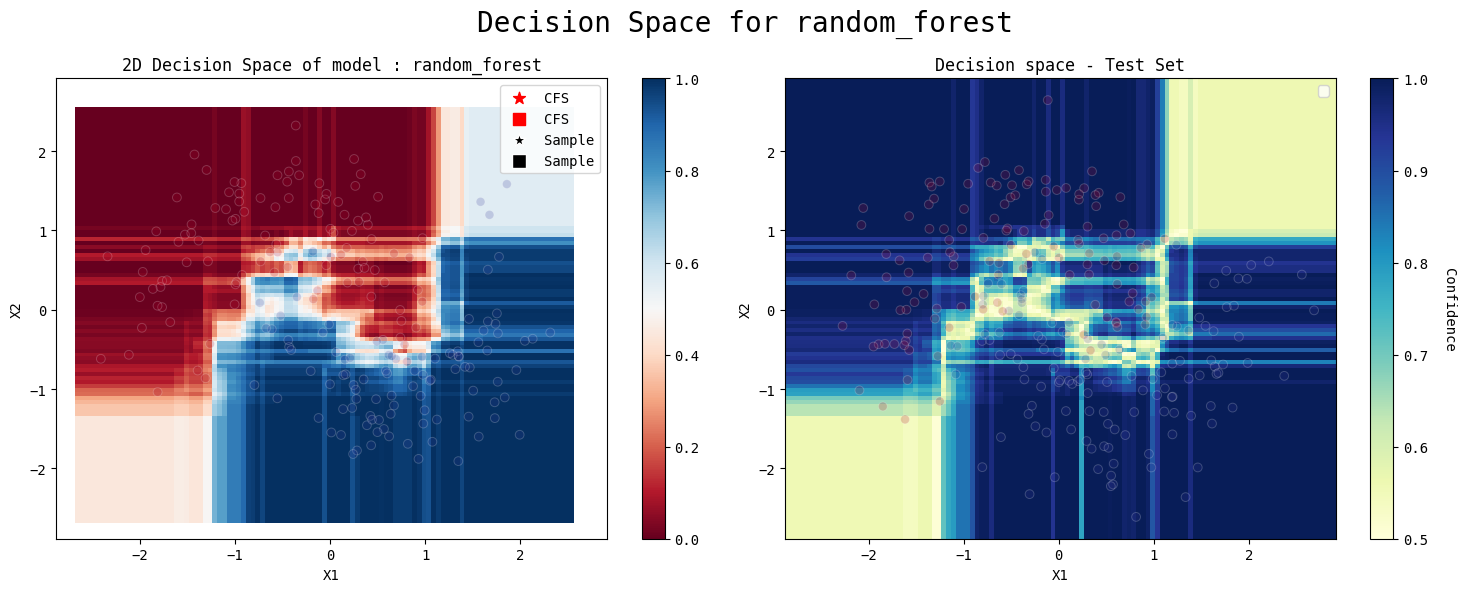

2025-07-26 14:34:40,935 matplotlib.legend WARNING  No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


I found 4 files
0) cf_results_lore_genetic_test_20250306_204606.npz
1) cf_results_ils_latent_test_20250216_163722.npz
2) cf_results_ils_random_test_20250209_222953.npz
3) cf_results_dice_kdtree_test_20250122_200233.npz
for model mlp using file cf_results_lore_genetic_test_20250306_204606.npz
checking cf_results_lore_genetic_test_20250306_204606.npz
Found 2 counterfactuals for model mlp
L2 distances computed (642,) (1, 2)
Original sample marker: *
original class was: 0      0
1      0
2      0
3      0
4      0
      ..
637    0
638    0
639    0
640    0
641    0
Name: target, Length: 642, dtype: int64
L2 distances computed (655,) (1, 2)
Original sample marker: s
original class was: 0      1
1      1
2      1
3      1
4      1
      ..
650    1
651    1
652    1
653    1
654    1
Name: target, Length: 655, dtype: int64
L2 distances computed (644,) (1, 2)
Original sample marker: *
original class was: 0      0
1      0
2      0
3      0
4      0
      ..
639    0
640    0
641    0
642   

In [ ]:

def plot_decision_space(my_model,model_name='',
                        draw_confidence=True,
                        X=None,y=None,
                        res = 0.1,
                        ax = None,
                        space_name="2D Decision Space of model "):
    """
        This funciton is used to plot the decision space of a model
    """
    x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
    y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
    x_max = y_max = max(x_max,y_max)
    y_min = x_min = min(x_min,y_min)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, res),
                            np.arange(y_min, y_max, res))

    if draw_confidence:
        Z = np.max(my_model.predict_proba(np.c_[xx.ravel(), yy.ravel()]),axis=1)
        cmap = plt.cm.YlGnBu    
    else:
        Z = my_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
        #cmap = plt.cm.RdYlBu.reversed()
        cmap = plt.cm.PiYG
        cmap = plt.cm.RdBu
    
    Z = Z.reshape(xx.shape)
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    vmax=1.0 if draw_confidence else float(len(set(y))-1)
    vmin=0.5 if draw_confidence else 0
    
    #plt.contourf(xx, yy, Z, alpha=0.8, cmap=cmap,
    #             vmin=vmin,vmax=vmax,
    #             levels=np.linspace(vmin,1.0,12))
    im = ax.pcolormesh(xx, yy, Z, cmap=cmap,vmin=vmin,vmax=vmax)
    
    plt.colorbar(im,ax=ax)
    # for the legend use the shaded color and the class labels: "predicted class i"
    #for i in range(0, len(set(y))):
    #    plt.scatter([], [], s=100, label="Class "+str(i),color=plt.cm.RdYlBu(i/len(set(y))),vmin=0,vmax=1)
    
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='white',
                linewidth=0.7,
                vmin=vmin,vmax=vmax,
                alpha=0.2,
                s=40)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.legend()
    if len(model_name)>0:
        model_name = ": "+str(model_name)
    ax.set_title(space_name+str(model_name))
    return ax

original_sample_color = "lightgreen"
original_sample_marker = "o"
cf_color = "red"
cf_marker = "x"
resol = 0.05

# the wrapper model takes as input the 2d points and returns the prediction of the model
# as the models in the models dictionary takes as input the original space, the initial step of the wrapper model is the inverse of the RBM
# the second step is the model itself
# inverse_rbm is the pipeline that takes the 2d points and returns the original space points
for k in models.keys():
    fig, axes = plt.subplots(1,2, figsize=(15, 6))
    axes = axes.flatten()
    wrapped_model = Pipeline(steps=[ # recreate now step by step the pipeline
        #("inverse_scaler", inverse_mapper.named_steps["scaler"]),
        ("inverse_mapper", inverse_mapper),
        #('scaler', models["mlp"].named_steps['scaler']),
        ('model', models[k].named_steps['model'])

    ])
    wrapped_model.predict(mapped_X)
    
    ax = plot_decision_space(wrapped_model,model_name=k,
                        X = X_cal_2d,y = wrapped_model.predict(X_cal_2d),
                        res=resol,
                        draw_confidence=False,
                        ax =axes[0])
    
    
   




    # now we plot the counterfactuals
    cfs = load_cf(k)
    if cfs is None:
        print("No counterfactuals found for model",k)
        continue
    else:
        print("Found",len(cfs),"counterfactuals for model",k)
    # plot the counterfactuals in the decision space
    for i in test_idx:
        cfs["cfs"][i]["counterfactuals"] = np.array(cfs["cfs"][i]["counterfactuals"])
        L2_dists = np.linalg.norm(cfs["cfs"][i]["counterfactuals"] - cfs["cfs"][i]["original_instance"], axis=1)
        print("L2 distances computed",L2_dists.shape,X_test.iloc[i:i+1].shape)
        original_sample_marker = "*" if models[k].predict(cfs["cfs"][i]["original_instance"])[0] else "s"
        print("Original sample marker:",original_sample_marker)
        #ax.scatter(X_test_2d[i, 0], X_test_2d[i, 1], marker=original_sample_marker,
        #            c=original_sample_color,s=100)
                # get the original class of the counterfactuals
        said_original_class = cfs["cfs"][i]["counterfactuals"].iloc[:,-1]

        true_original_class = models[k].predict(cfs["cfs"][i]["counterfactuals"].iloc[:,:-1])
        pred = models[k].predict(cfs["cfs"][i]["counterfactuals"].iloc[:,:-1])
        # check that the original class is the same as the predicted class
        if not np.all(true_original_class == pred):
            print("Warning: the original class of the counterfactuals is not the same as the predicted class")
            print("Said original class:",said_original_class)
            print("Predicted class:",pred)
        else:
            print("original class was:",said_original_class.values.mean())
            continue


        ax.scatter(X_test_2d[i, 0], X_test_2d[i, 1], marker=original_sample_marker,
                    c="k",s=100,edgecolors="white",linewidth=1)

        # take only the closest 4 counterfactuals
        closest_cfs = np.argsort(L2_dists)[:4]
        # plot the counterfactuals in the decision space
        
        cf_markers = ["$"+str(p)+"$" for p in pred]
        
        mapped_cfs = mapper_.transform(cfs["cfs"][i]["counterfactuals"].iloc[:,:-1])# exclude the last column which is the label
        print(len(pred),(pred==1).sum())
        if pred.sum() == 0:
            ax.scatter(mapped_cfs[pred==0][closest_cfs, 0], mapped_cfs[pred==0][closest_cfs, 1], marker="s", color=cf_color,s=80)
        else:
            ax.scatter(mapped_cfs[pred==1][closest_cfs, 0], mapped_cfs[pred==1][closest_cfs, 1], marker="*", color=cf_color,s=80)

        said_original_class = said_original_class.values[closest_cfs]

        # draw a line between the original instance and the counterfactuals
        for j in closest_cfs:
            ax.plot([X_test_2d[i, 0], mapped_cfs[j, 0]], [X_test_2d[i, 1], mapped_cfs[j, 1]], color='white', linestyle='--', linewidth=0.5)
    ax.scatter([],[], marker="*", color=cf_color, s=80, label="CFS")
    ax.scatter([],[], marker="s", color=cf_color, s=80, label="CFS")
    ax.scatter([],[], marker="*", color="k", s=100, label="Sample",edgecolors="white",linewidth=1)
    ax.scatter([],[], marker="s", color="k", s=100, label="Sample",edgecolors="white",linewidth=1)

    

    ax.legend()

    compute_test = True


    ax = plot_decision_space(wrapped_model,model_name=k,
                        X = X_test_2d,y = wrapped_model.predict(X_test_2d),
                        res=resol,
                        draw_confidence=True,
                        ax=axes[1])

    ax.set_title("Decision space - Test Set")
    # add the label for the color bar
    # get the colorbar from the previous plot
    cbar = ax.collections[0].colorbar
    if cbar is not None:
        cbar.set_label('Confidence', rotation=270, labelpad=20)

    
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()
    for ax in axes:
        xlims = (min(xlims[0],ax.get_xlim()[0]),max(xlims[1],ax.get_xlim()[1]))
        ylims = (min(ylims[0],ax.get_ylim()[0]),max(ylims[1],ax.get_ylim()[1]))
    for ax in axes:
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
    plt.suptitle("Decision Space for "+k,fontsize=20)
    plt.tight_layout()



    fig_name = os.path.join("plots",dt_name,
                            "decision_space_"+k+".pdf")
    #plt.savefig(fig_name) # PNG is better
    plt.savefig(fig_name.replace(".pdf",".png"))
    plt.savefig(fig_name)
    #if k=='mlp':
    plt.show()
    plt.close(fig)
    

In [ ]:
# We'll plot the calibration points in the 2D mapped space, colored by their mean L2 distance from the loaded ranking file.
# We'll use the 'all_stats' dictionary, which contains the distances for each model.

for k in models.keys():
    # Get the mean L2 distances for calibration points
    l2_means = all_stats[k]['distances']['l2']['mean']
    # Map calibration points to 2D
    X_cal_2d = mapper_.transform(splits['X_calibration'])
    
    plt.figure(figsize=(8, 7))
    scatter = plt.scatter(X_cal_2d[:, 0], X_cal_2d[:, 1], c=l2_means, cmap='viridis', s=40, edgecolor='k', alpha=0.8)
    plt.colorbar(scatter, label='Mean L2 Distance')
    plt.title(f'Calibration Points Colored by Mean L2 Distance ({k})')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()